## The Task is to clean the dataset of the New York City Airbnb Open Data and perform Data Cleaning and Preprocessing.

This notebook provides a comprehensive implementation of data cleaning and preprocessing with proper functions and methods.

### Importing specific libraries for data cleaning and preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

### Load and explore the dataset

In [2]:
# Loading the dataset
df = pd.read_csv('AB_NYC_2019.csv')
print('Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# Copying the dataset for cleaning and preprocessing
df_copy = df.copy()
print('The shape of the copied dataset is:', df_copy.shape)
print('The columns in the copied dataset are:', df_copy.columns)
print(df_copy.info())
display(df_copy.describe())

The shape of the copied dataset is: (48895, 16)
The columns in the copied dataset are: Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6  

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## Data Cleaning and Preprocessing Implementation

In [4]:
# Check for missing values
print('The number of missing values in each column is:')
missing_count = df_copy.isnull().sum()
missing_percentage = (df_copy.isnull().sum() / len(df_copy)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)
print(f'\nTotal missing values: {missing_count.sum()}')

The number of missing values in each column is:
               Column  Missing_Count  Percentage
13  reviews_per_month          10052   20.558339
12        last_review          10052   20.558339
3           host_name             21    0.042949
1                name             16    0.032723

Total missing values: 20141


### Step 1: Handle Missing Values

In [5]:
def handle_missing_values(df):
    """
    Handle missing values in the dataset using strategic methods
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe with missing values
    
    Returns:
    pandas.DataFrame
        Dataframe with missing values handled
    """
    print('\n' + '='*60)
    print('HANDLING MISSING VALUES')
    print('='*60)
    
    # Handle 'name' column - fill with 'Unknown'
    initial_name_missing = df['name'].isnull().sum()
    df['name'] = df['name'].fillna('Unknown Listing')
    print(f"✓ 'name': Filled {initial_name_missing} missing values with 'Unknown Listing'")
    
    # Handle 'host_name' column - fill with 'Unknown'
    initial_hostname_missing = df['host_name'].isnull().sum()
    df['host_name'] = df['host_name'].fillna('Unknown Host')
    print(f"✓ 'host_name': Filled {initial_hostname_missing} missing values with 'Unknown Host'")
    
    # Handle 'last_review' - fill with 'No Review'
    initial_review_missing = df['last_review'].isnull().sum()
    df['last_review'] = df['last_review'].fillna('No Review')
    print(f"✓ 'last_review': Filled {initial_review_missing} missing values with 'No Review'")
    
    # Handle 'reviews_per_month' - fill with 0.0
    initial_rpm_missing = df['reviews_per_month'].isnull().sum()
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)
    print(f"✓ 'reviews_per_month': Filled {initial_rpm_missing} missing values with 0.0")
    
    return df

# Apply missing values handling
df_copy = handle_missing_values(df_copy)


HANDLING MISSING VALUES
✓ 'name': Filled 16 missing values with 'Unknown Listing'
✓ 'host_name': Filled 21 missing values with 'Unknown Host'
✓ 'last_review': Filled 10052 missing values with 'No Review'
✓ 'reviews_per_month': Filled 10052 missing values with 0.0


### Step 2: Handle Duplicates

In [6]:
def handle_duplicates(df):
    """
    Identify and handle duplicate records
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    
    Returns:
    pandas.DataFrame
        Dataframe with duplicates removed
    """
    print('\n' + '='*60)
    print('HANDLING DUPLICATES')
    print('='*60)
    
    # Check for complete duplicates
    complete_duplicates = df.duplicated().sum()
    print(f"\nComplete duplicates found: {complete_duplicates}")
    
    # Check for duplicate IDs
    duplicate_ids = df[df['id'].duplicated()].shape[0]
    print(f"Duplicate IDs found: {duplicate_ids}")
    
    if complete_duplicates > 0:
        df = df.drop_duplicates()
        print(f"✓ Removed {complete_duplicates} complete duplicate rows")
    else:
        print("✓ No duplicates found")
    
    return df

# Apply duplicate handling
df_copy = handle_duplicates(df_copy)


HANDLING DUPLICATES

Complete duplicates found: 0
Duplicate IDs found: 0
✓ No duplicates found


### Step 3: Convert Data Types

In [7]:
def convert_data_types(df):
    """
    Convert columns to appropriate data types
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    
    Returns:
    pandas.DataFrame
        Dataframe with converted data types
    """
    print('\n' + '='*60)
    print('CONVERTING DATA TYPES')
    print('='*60)
    
    # Convert last_review to datetime
    df['last_review_date'] = pd.to_datetime(df['last_review'], errors='coerce')
    valid_dates = df['last_review_date'].notna().sum()
    print(f"\n✓ Converted 'last_review' to datetime")
    print(f"  Valid dates: {valid_dates}")
    print(f"  Invalid/No Review: {df['last_review_date'].isna().sum()}")
    
    # Convert categorical columns
    categorical_cols = ['neighbourhood_group', 'room_type']
    for col in categorical_cols:
        df[col] = df[col].astype('category')
    print(f"\n✓ Converted categorical columns: {categorical_cols}")
    
    # Ensure numeric columns
    numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 
                   'reviews_per_month', 'availability_365']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"✓ Ensured numeric columns: {numeric_cols}")
    
    return df

# Apply data type conversion
df_copy = convert_data_types(df_copy)


CONVERTING DATA TYPES

✓ Converted 'last_review' to datetime
  Valid dates: 38843
  Invalid/No Review: 10052

✓ Converted categorical columns: ['neighbourhood_group', 'room_type']
✓ Ensured numeric columns: ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']


### Step 4: Identify and Handle Outliers

In [8]:
def identify_outliers_iqr(df, column):
    """
    Identify outliers using Interquartile Range (IQR) method
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    column : str
        Column name to check for outliers
    
    Returns:
    tuple
        (outlier_mask, statistics_dict)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    
    stats_dict = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_mask.sum(),
        'outlier_percentage': (outlier_mask.sum() / len(df)) * 100
    }
    
    return outlier_mask, stats_dict

def handle_outliers(df, columns_config=None):
    """
    Handle outliers in specified columns
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    columns_config : dict
        Configuration for outlier handling
    
    Returns:
    pandas.DataFrame
        Dataframe with outliers handled
    """
    print('\n' + '='*60)
    print('HANDLING OUTLIERS')
    print('='*60)
    
    if columns_config is None:
        columns_config = {
            'price': {'action': 'remove'},
            'minimum_nights': {'action': 'remove'}
        }
    
    initial_rows = len(df)
    
    for column, config in columns_config.items():
        if column not in df.columns:
            print(f"⚠ Column '{column}' not found")
            continue
        
        outlier_mask, stats_dict = identify_outliers_iqr(df, column)
        
        print(f"\n{column}:")
        print(f"  Lower bound: {stats_dict['lower_bound']:.2f}")
        print(f"  Upper bound: {stats_dict['upper_bound']:.2f}")
        print(f"  Outliers found: {stats_dict['outlier_count']} ({stats_dict['outlier_percentage']:.2f}%)")
        
        if config['action'] == 'remove':
            df = df[~outlier_mask]
            print(f"  ✓ Removed {stats_dict['outlier_count']} outlier rows")
    
    rows_removed = initial_rows - len(df)
    print(f"\nTotal rows after outlier handling: {len(df)} (removed: {rows_removed})")
    
    return df

# Apply outlier handling
df_copy = handle_outliers(df_copy, {
    'price': {'action': 'remove'},
    'minimum_nights': {'action': 'remove'}
})


HANDLING OUTLIERS

price:
  Lower bound: -90.00
  Upper bound: 334.00
  Outliers found: 2972 (6.08%)
  ✓ Removed 2972 outlier rows

minimum_nights:
  Lower bound: -5.00
  Upper bound: 11.00
  Outliers found: 6185 (13.47%)
  ✓ Removed 6185 outlier rows

Total rows after outlier handling: 39738 (removed: 9157)


### Step 5: Handle Anomalies

In [9]:
def handle_anomalies(df):
    """
    Handle specific data anomalies
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    
    Returns:
    pandas.DataFrame
        Dataframe with anomalies handled
    """
    print('\n' + '='*60)
    print('HANDLING ANOMALIES')
    print('='*60)
    
    initial_rows = len(df)
    
    # Remove listings with price = 0
    zero_price = (df['price'] == 0).sum()
    if zero_price > 0:
        df = df[df['price'] > 0]
        print(f"\n✓ Removed {zero_price} listings with price = $0")
    
    # Validate latitude and longitude ranges for NYC
    nyc_lat_min, nyc_lat_max = 40.5, 40.95
    nyc_lon_min, nyc_lon_max = -74.3, -73.7
    
    invalid_coords = (
        (df['latitude'] < nyc_lat_min) | 
        (df['latitude'] > nyc_lat_max) |
        (df['longitude'] < nyc_lon_min) | 
        (df['longitude'] > nyc_lon_max)
    ).sum()
    
    if invalid_coords > 0:
        df = df[
            (df['latitude'] >= nyc_lat_min) & 
            (df['latitude'] <= nyc_lat_max) &
            (df['longitude'] >= nyc_lon_min) & 
            (df['longitude'] <= nyc_lon_max)
        ]
        print(f"✓ Removed {invalid_coords} listings with invalid coordinates")
    
    # Validate availability_365 range
    invalid_avail = ((df['availability_365'] < 0) | 
                    (df['availability_365'] > 365)).sum()
    if invalid_avail > 0:
        df = df[
            (df['availability_365'] >= 0) & 
            (df['availability_365'] <= 365)
        ]
        print(f"✓ Removed {invalid_avail} listings with invalid availability values")
    
    total_removed = initial_rows - len(df)
    print(f"\nTotal rows after anomaly handling: {len(df)} (removed: {total_removed})")
    
    return df

# Apply anomaly handling
df_copy = handle_anomalies(df_copy)


HANDLING ANOMALIES

✓ Removed 9 listings with price = $0
✓ Removed 1 listings with invalid coordinates

Total rows after anomaly handling: 39728 (removed: 10)


### Step 6: Validate Cleaned Data

In [10]:
def validate_cleaned_data(df, df_original):
    """
    Validate the cleaned dataset
    
    Parameters:
    df : pandas.DataFrame
        Cleaned dataframe
    df_original : pandas.DataFrame
        Original dataframe for comparison
    
    Returns:
    dict
        Validation results
    """
    print('\n' + '='*60)
    print('DATA VALIDATION REPORT')
    print('='*60)
    
    validation_results = {
        'original_rows': len(df_original),
        'cleaned_rows': len(df),
        'rows_removed': len(df_original) - len(df),
        'retention_percentage': (len(df) / len(df_original)) * 100,
        'total_columns': len(df.columns),
        'missing_values': df.isnull().sum().sum(),
        'duplicate_rows': df.duplicated().sum(),
        'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2
    }
    
    print(f"\n✓ Original rows: {validation_results['original_rows']}")
    print(f"✓ Cleaned rows: {validation_results['cleaned_rows']}")
    print(f"✓ Rows removed: {validation_results['rows_removed']}")
    print(f"✓ Retention: {validation_results['retention_percentage']:.1f}%")
    print(f"✓ Total columns: {validation_results['total_columns']}")
    print(f"✓ Missing values: {validation_results['missing_values']}")
    print(f"✓ Duplicate rows: {validation_results['duplicate_rows']}")
    print(f"✓ Memory usage: {validation_results['memory_usage_mb']:.2f} MB")
    
    print(f"\nData types:")
    print(df.dtypes)
    
    print(f"\nStatistical Summary:")
    display(df.describe())
    
    return validation_results

# Validate cleaned data
validation_results = validate_cleaned_data(df_copy, df)


DATA VALIDATION REPORT

✓ Original rows: 48895
✓ Cleaned rows: 39728
✓ Rows removed: 9167
✓ Retention: 81.3%
✓ Total columns: 17
✓ Missing values: 6699
✓ Duplicate rows: 0
✓ Memory usage: 13.67 MB

Data types:
id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                     category
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                               category
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                               object
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
last_

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_date
count,3.972800e+04,3.972800e+04,39728.000000,39728.000000,39728.000000,39728.000000,39728.000000,39728.000000,39728.000000,39728.000000,33029
mean,1.883331e+07,6.622055e+07,40.727581,-73.949143,119.028443,2.696260,26.374874,1.232005,3.072921,97.163537,2018-10-08 03:41:12.990402304
min,2.539000e+03,2.571000e+03,40.506410,-74.244420,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2011-03-28 00:00:00
25%,9.414515e+06,7.823977e+06,40.688080,-73.981043,65.000000,1.000000,1.000000,0.070000,1.000000,0.000000,2018-07-13 00:00:00
50%,1.947202e+07,3.073608e+07,40.720080,-73.953320,100.000000,2.000000,7.000000,0.510000,1.000000,25.000000,2019-05-26 00:00:00
75%,2.861498e+07,1.036288e+08,40.763270,-73.932190,155.000000,3.000000,29.000000,1.890000,2.000000,179.000000,2019-06-24 00:00:00
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,11.000000,629.000000,58.500000,327.000000,365.000000,2019-07-08 00:00:00
std,1.084454e+07,7.750813e+07,0.056284,0.047689,67.168822,1.863652,47.475969,1.683419,19.746321,124.367214,NaN


### Step 7: Save Cleaned Data

In [11]:
# Save the cleaned dataset
output_file = 'AB_NYC_2019_cleaned.csv'
df_copy.to_csv(output_file, index=False)

print('\n' + '='*60)
print('SAVING CLEANED DATA')
print('='*60)
print(f"\n✓ Cleaned dataset saved to: {output_file}")
print(f"  Shape: {df_copy.shape}")
print(f"  File size: {df_copy.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


SAVING CLEANED DATA

✓ Cleaned dataset saved to: AB_NYC_2019_cleaned.csv
  Shape: (39728, 17)
  File size: 13.67 MB


### Step 8: Create Visualizations


CREATING VISUALIZATIONS


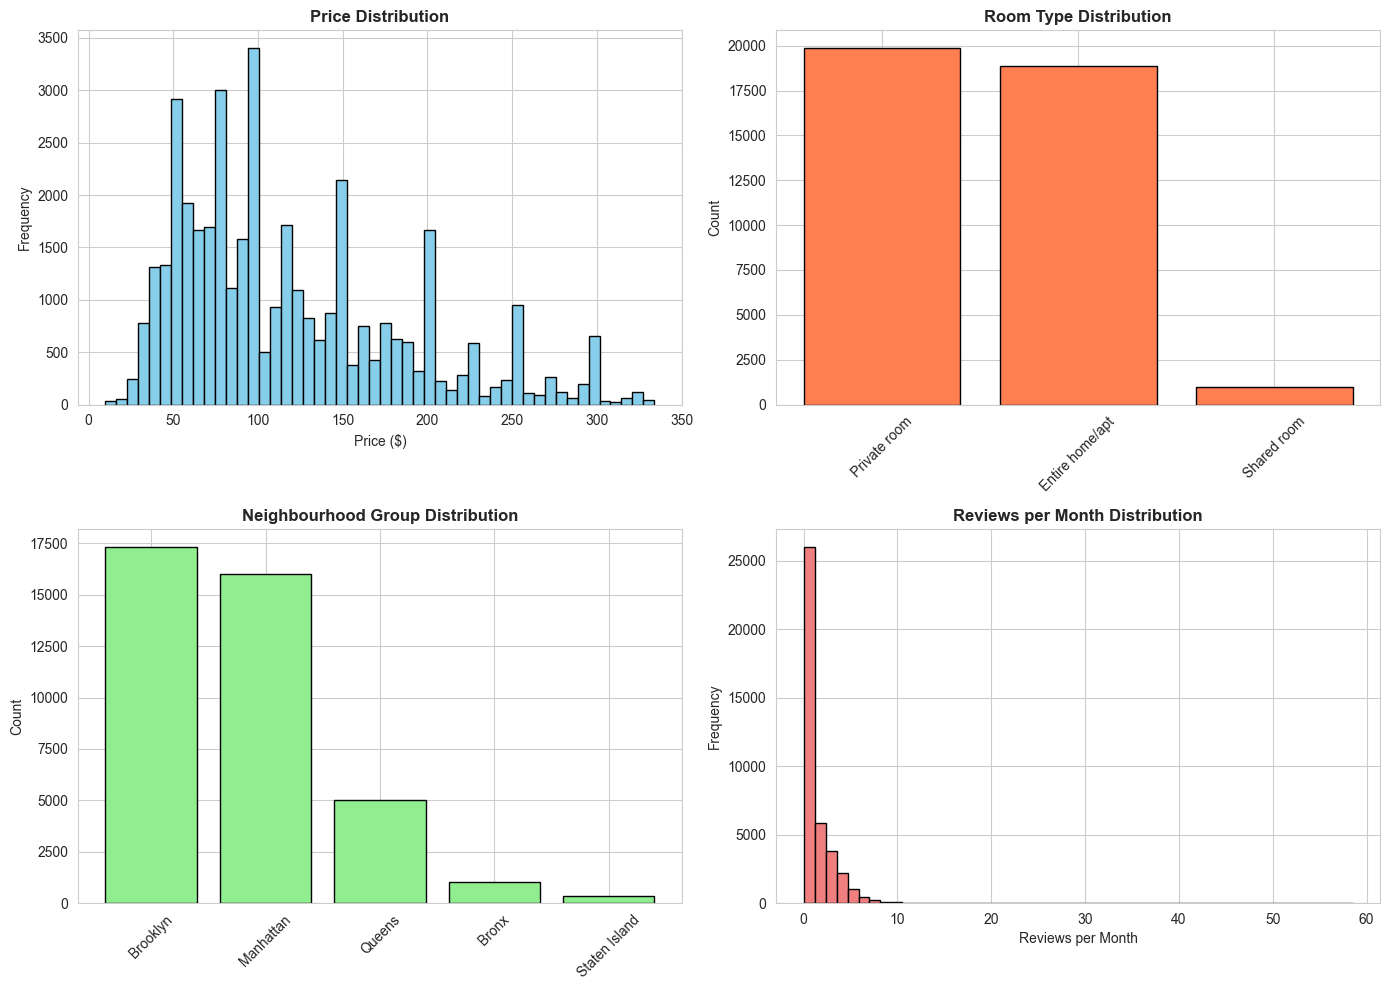

In [18]:
# Create comprehensive visualizations
print('\n' + '='*60)
print('CREATING VISUALIZATIONS')
print('='*60)

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price distribution
axes[0, 0].hist(df_copy['price'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# 2. Room type distribution
room_counts = df_copy['room_type'].value_counts()
axes[0, 1].bar(room_counts.index, room_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Room Type Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Neighbourhood group distribution
ng_counts = df_copy['neighbourhood_group'].value_counts()
axes[1, 0].bar(ng_counts.index, ng_counts.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Neighbourhood Group Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Reviews per month
axes[1, 1].hist(df_copy['reviews_per_month'], bins=50, edgecolor='black', color='lightcoral')
axes[1, 1].set_title('Reviews per Month Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Reviews per Month')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

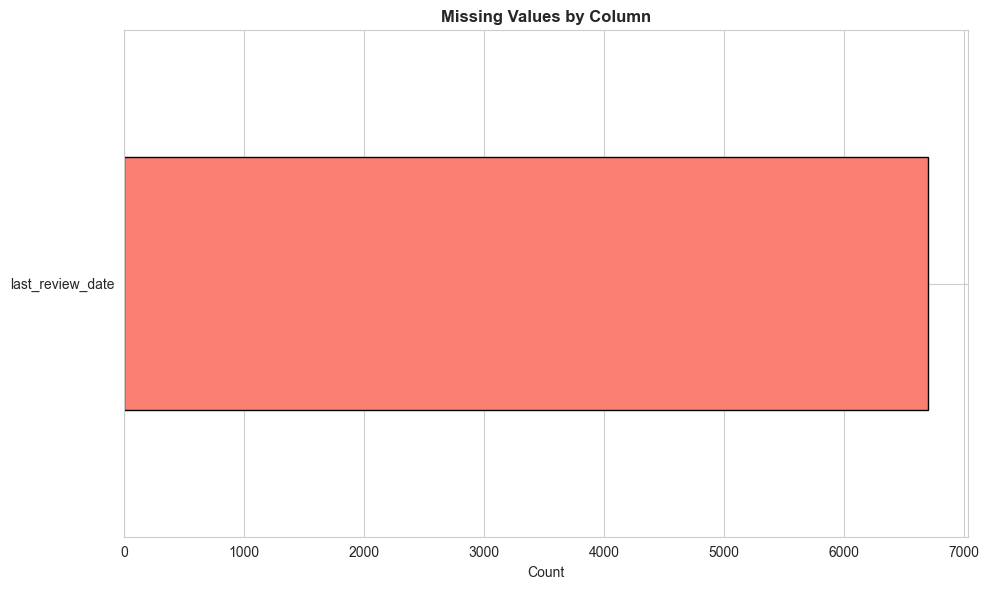

In [17]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_data = df_copy.isnull().sum()
if missing_data.sum() > 0:
    missing_data[missing_data > 0].plot(kind='barh', ax=ax, color='salmon', edgecolor='black')
    ax.set_title('Missing Values by Column', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
else:
    ax.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    ax.set_title('Missing Values Analysis', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Cleaning Summary Report

In [14]:
# Generate comprehensive summary report
report = f"""
{'='*60}
DATA CLEANING SUMMARY REPORT
{'='*60}

Initial Dataset Shape: {df.shape}
Final Dataset Shape: {df_copy.shape}

Rows Removed: {df.shape[0] - df_copy.shape[0]}
Rows Retained: {df_copy.shape[0]} ({(df_copy.shape[0]/df.shape[0]*100):.1f}%)

Operations Performed:
  ✓ Handled missing values (name, host_name, last_review, reviews_per_month)
  ✓ Checked and handled duplicates
  ✓ Converted data types (categorical, datetime, numeric)
  ✓ Removed outliers using IQR method
  ✓ Fixed data anomalies (zero prices, invalid coordinates)
  ✓ Created data quality visualizations

Output File: {output_file}
Memory Usage: {df_copy.memory_usage(deep=True).sum() / 1024**2:.2f} MB

Data Quality Metrics:
  - Total Records: {len(df_copy)}
  - Total Columns: {len(df_copy.columns)}
  - Missing Values: {df_copy.isnull().sum().sum()}
  - Duplicate Rows: {df_copy.duplicated().sum()}

{'='*60}
"""

print(report)


DATA CLEANING SUMMARY REPORT

Initial Dataset Shape: (48895, 16)
Final Dataset Shape: (39728, 17)

Rows Removed: 9167
Rows Retained: 39728 (81.3%)

Operations Performed:
  ✓ Handled missing values (name, host_name, last_review, reviews_per_month)
  ✓ Checked and handled duplicates
  ✓ Converted data types (categorical, datetime, numeric)
  ✓ Removed outliers using IQR method
  ✓ Fixed data anomalies (zero prices, invalid coordinates)
  ✓ Created data quality visualizations

Output File: AB_NYC_2019_cleaned.csv
Memory Usage: 13.67 MB

Data Quality Metrics:
  - Total Records: 39728
  - Total Columns: 17
  - Missing Values: 6699
  - Duplicate Rows: 0




## Cleaned Data Sample

In [15]:
# Display sample of cleaned data
print("\nCleaned Data Sample:")
display(df_copy.head(10))


Cleaned Data Sample:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_date
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,2018-10-19
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2019-05-21
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,NaT
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,2019-07-05
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,2018-11-19
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,2019-06-22
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220,2019-06-24
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0,2017-07-21
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188,2019-06-09
10,5295,Beautiful 1br on Upper West Side,7702,Lena,Manhattan,Upper West Side,40.80316,-73.96545,Entire home/apt,135,5,53,2019-06-22,0.43,1,6,2019-06-22


In [16]:
# Final statistics of cleaned data
print('\nFinal Dataset Info:')
print(df_copy.info())
print('\nData Quality Metrics:')
print(f'Total Records: {len(df_copy)}')
print(f'Total Columns: {len(df_copy.columns)}')
print(f'Missing Values: {df_copy.isnull().sum().sum()}')
print(f'Duplicate Rows: {df_copy.duplicated().sum()}')
print(f'\nDataset Ready for Further Analysis!')


Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 39728 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              39728 non-null  int64         
 1   name                            39728 non-null  object        
 2   host_id                         39728 non-null  int64         
 3   host_name                       39728 non-null  object        
 4   neighbourhood_group             39728 non-null  category      
 5   neighbourhood                   39728 non-null  object        
 6   latitude                        39728 non-null  float64       
 7   longitude                       39728 non-null  float64       
 8   room_type                       39728 non-null  category      
 9   price                           39728 non-null  int64         
 10  minimum_nights                  39728 non-null  int64 